# Лабораторна 1. Загальний пайплайн навчання.

В цій лабораторній роботі студенти тренують моделі машинного навчання
на базі простих регресій: лінійна, логістична, поліноміальна.
Ознайомлюються з базовими поняттями: спліт та  нормалізація даних, захист протікання даних (data leakage),
чистка, логування.

Працюємо в Google Colab.


## 0. Налаштування середовища

### 0.0. Імпортуємо залежності

In [2]:
import sys
import os
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

### 0.1. Перевіряємо чи ми точно в Colab

In [3]:
IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)

assert IN_COLAB, f"Ця лаба має вокинуватися в Google Colab (https://colab.research.google.com/)"

Running in Colab: True


### 0.2. Фіксуємо всі джерела випадковості.
На GPU повна детермінованість трохи сповільнює тренування
(`cudnn.deterministic = True` вимикає частину швидких алгоритмів) —
тут це не критично, адже дані й модель дрібні.

In [4]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

**Вправа 1.** Скористайся вбудованим модулем `random`. Спробуй `random.randint(1, 100)` і `random.shuffle()` на списку — випадковість буває не лише в числі, а й у перестановці. Згенеруй обома способами двічі ДО виклику `set_seed()` — переконайся, що результати різні. Потім ще двічі ПІСЛЯ, викликаючи `set_seed()`. Після клітинки з кодом створи клітинку з маркдауном і поясни що відбувається після `set_seed()` і як це проявляється в результатах виконання коду.

In [5]:
numbers = list(range(10))  # список для shuffle

print("До set_seed:")

numbers1 = list(range(10))
print("randint:", random.randint(1, 100))
random.shuffle(numbers1)
print("shuffle:", numbers1)

numbers2 = list(range(10))
print("randint:", random.randint(1, 100))
random.shuffle(numbers2)
print("shuffle:", numbers2)

# Фіксуємо seed
set_seed()
print("\nSeed зафіксовано:", SEED)

print("\nПісля set_seed:")

set_seed()
numbers3 = list(range(10))
print("randint:", random.randint(1, 100))
random.shuffle(numbers3)
print("shuffle:", numbers3)

set_seed()
numbers4 = list(range(10))
print("randint:", random.randint(1, 100))
random.shuffle(numbers4)
print("shuffle:", numbers4)

До set_seed:
randint: 11
shuffle: [1, 9, 7, 6, 3, 5, 2, 4, 0, 8]
randint: 32
shuffle: [9, 2, 8, 7, 0, 4, 3, 6, 5, 1]

Seed зафіксовано: 42

Після set_seed:
randint: 82
shuffle: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]
randint: 82
shuffle: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]


### 0.3. Використовуємо лише CPU (в цій лабі)
На Colab зазвичай є безкоштовний GPU (T4), але для лінійної регресії
на кількасот точок CPU часто не повільніший — виграш GPU з'їдає пересилання
даних на пристрій і назад щоепохи. Тому нижче свідомо тренуємось на CPU.

In [6]:
device_available = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

print("Доступний пристрій :", device_available)
print("Використовуємо     :", device)
if device_available.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

assert device.type == "cpu", f"Ця лаба має виконуватися на CPU, а не на GPU ({device})"

Доступний пристрій : cuda
Використовуємо     : cpu
GPU: Tesla T4


**Вправа 2.** Встанови CPU рантайм. Запусти комірку вище і зроби скріншот виводу. Потім у Colab зміни рантайм на GPU, перезапусти всі комірки від початку. Знову зроби скріншот тієї самої комірки. Збережи обидва скріншоти — пізніше завантажиш їх на GitHub разом зі здачею лаби.

### 0.4. Монтуємо Google Drive

Сесія Colab обмежена в часі й може скинутись — усе в `/content` зникає разом
з нею. Монтуємо Drive, щоб чекпоінт моделі й логи TensorBoard пережили
перезапуск.

In [7]:
from google.colab import drive
drive.mount("/content/drive")
ARTIFACT_DIR = "/content/drive/MyDrive/ai_systems/lab1"


os.makedirs(ARTIFACT_DIR, exist_ok=True)
RUNS_DIR = os.path.join(ARTIFACT_DIR, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)
print("Артефакти зберігаються в:", ARTIFACT_DIR)


Mounted at /content/drive
Артефакти зберігаються в: /content/drive/MyDrive/ai_systems/lab1


---
## 1. Ознайомлення з бібліотеками

Кілька дуже простих вправ на NumPy, pandas, PyTorch і Matplotlib — щоб мати
спільну базу перед тим, як усі чотири підуть у хід одночасно.

### 1.1. NumPy

Документація: https://numpy.org/doc/stable/

**Вправа 3.** Створи масив форми 3×4, заповнений нулями (`np.zeros`), і ще один такої самої форми, заповнений числом 7 (`np.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [8]:
# Масив 3×4, заповнений нулями
zeros_arr = np.zeros((3, 4))

# Масив 3×4, заповнений сімками
sevens_arr = np.full((3, 4), 7)

print(
    zeros_arr,
    zeros_arr.shape,
    zeros_arr.dtype
)

print(
    sevens_arr,
    sevens_arr.shape,
    sevens_arr.dtype
)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] (3, 4) float64
[[7 7 7 7]
 [7 7 7 7]
 [7 7 7 7]] (3, 4) int64


**Вправа 4.** Створи масив від 0 до 20 із кроком 2 через `np.arange`, і масив із 5 рівномірно розподілених точок від 0 до 1 через `np.linspace`. Виведи обидва.

In [9]:
arange_arr = np.arange(0, 20, 2)

linspace_arr = np.linspace(0, 1, 5)

print(arange_arr)
print(linspace_arr)


[ 0  2  4  6  8 10 12 14 16 18]
[0.   0.25 0.5  0.75 1.  ]


**Вправа 5.** Створи одиничну матрицю 4×4 (`np.eye`) і випадковий масив цілих чисел форми 3×3 у діапазоні [0, 10) (`np.random.randint`). Виведи `.ndim` обох масивів.

In [10]:
identity = np.eye(4)

random_ints = np.random.randint(0, 10, size=(3, 3))

print(identity)
print(random_ints)

[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[6 3 7]
 [4 6 9]
 [2 6 7]]


**Вправа 6.** Маєш масив оцінок студентів. Порахуй середнє, стандартне відхилення і z-normalized версію масиву — без циклів.

In [11]:
scores = np.array([78, 85, 92, 67, 90, 74, 88, 95, 60, 82])

mean = np.mean(scores)
std = np.std(scores)
z_scores = (scores - mean) / std

print("Середнє:", mean, " Std:", std)
print("Z-scores:", z_scores)

Середнє: 81.1  Std: 10.76522178127325
Z-scores: [-0.28796434  0.36227772  1.01251978 -1.30977329  0.82673633 -0.65953123
  0.64095289  1.29119495 -1.96001536  0.08360255]


**Вправа 7.** Маєш 1D масив із 12 чисел. Перетвори його на матрицю 3×4 і порахуй суму кожного рядка та кожного стовпця.

In [12]:
arr = np.arange(1, 13)

matrix = arr.reshape(3, 4)

row_sums = matrix.sum(axis=1)
col_sums = matrix.sum(axis=0)

print(matrix)

print("Сума по рядках:  ", row_sums)
print("Сума по стовпцях:", col_sums)


[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Сума по рядках:   [10 26 42]
Сума по стовпцях: [15 18 21 24]


### 1.2. pandas

Документація: https://pandas.pydata.org/docs/

**Вправа 8.** Створи таблицю студентів з оцінками. Виведи тільки тих, хто набрав більше 80 балів, відсортованих за спаданням оцінки.

In [13]:
df = pd.DataFrame({
    "name": ["Андрій", "Олег", "Марія", "Ірина", "Максим", "Анна"],
    "score": [78, 95, 88, 72, 91, 84]
})

top = df[df["score"] > 80].sort_values("score", ascending=False)

print(top)

     name  score
1    Олег     95
4  Максим     91
2   Марія     88
5    Анна     84


**Вправа 9.** Додай колонку `grade`: `A` якщо `score >= 90`, `B` якщо `score >= 75`, інакше `C`.

In [14]:
df["grade"] = np.where(
    df["score"] >= 90,
    "A",
    np.where(
        df["score"] >= 75,
        "B",
        "C"
    )
)

print(df)


     name  score grade
0  Андрій     78     B
1    Олег     95     A
2   Марія     88     B
3   Ірина     72     C
4  Максим     91     A
5    Анна     84     B


### 1.3. PyTorch

Документація: https://pytorch.org/docs/stable/index.html

**Вправа 10.** Створи тензор форми 2×3, заповнений нулями (`torch.zeros`), і ще один такої самої форми, заповнений числом 7 (`torch.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [15]:
zeros_t = torch.zeros((2, 3))

sevens_t = torch.full((2, 3), 7)

print(zeros_t)
print(sevens_t)


tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([[7, 7, 7],
        [7, 7, 7]])


**Вправа 11.** Створи тензор від 0 до 20 із кроком 2 через `torch.arange`, і тензор із 5 рівномірно розподілених точок від 0 до 1 через `torch.linspace`.

In [16]:
arange_t = torch.arange(0, 20, 2)
linspace_t = torch.linspace(0, 1, 5)

print(arange_t)
print(linspace_t)


tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])
tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


**Вправа 12.** Створи тензор напряму зі списку — `torch.tensor([[1, 2], [3, 4]])` — і випадковий тензор форми 3×3 через `torch.rand`. Виведи `.shape`, `.dtype` і `.ndim` обох.

In [17]:
from_list = torch.tensor([[1, 2], [3, 4]])
random_t = torch.rand(3, 3)

print(from_list)
print(random_t)

tensor([[1, 2],
        [3, 4]])
tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009],
        [0.2566, 0.7936, 0.9408]])


**Вправа 13.** Створи тензор `x = 5.0` з `requires_grad=True`, порахуй `y = x**2` і перевір автоматичний градієнт проти аналітичного ($dy/dx = 2x$).

In [18]:
n = 5.0

x = torch.tensor(n, requires_grad=True)
y = x ** 2
y.backward()

print(x.grad.item())
print(2 * n)

10.0
10.0


**Вправа 14.** Знайди $x$, який мінімізує $(x-3)^2 + 5$ — не аналітично, а градієнтним спуском: `x` як параметр з `requires_grad=True`, без жодної моделі.

In [19]:
x = torch.tensor(0.0, requires_grad=True)
lr = 0.1

for step in range(20):
    loss = (x - 3) ** 2 + 5
    loss.backward()

    with torch.no_grad():
        x -= lr * x.grad

    x.grad.zero_()

print(f"x = {x.item():.4f}  (мінімум у x=3)")


x = 2.9654  (мінімум у x=3)


### 1.4. Matplotlib

Документація: https://matplotlib.org/stable/index.html

**Вправа 15.** Побудуй графік функції $y = \sin(x)$ на проміжку $[0, 2\pi]$.

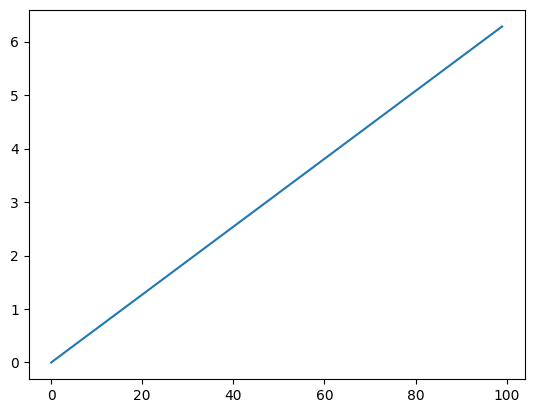

In [20]:
xs = np.linspace(0, 2 * np.pi, 100)

plt.plot(xs)
plt.show()


**Вправа 16.** На одному графіку познач дві групи точок різними кольорами і додай легенду.

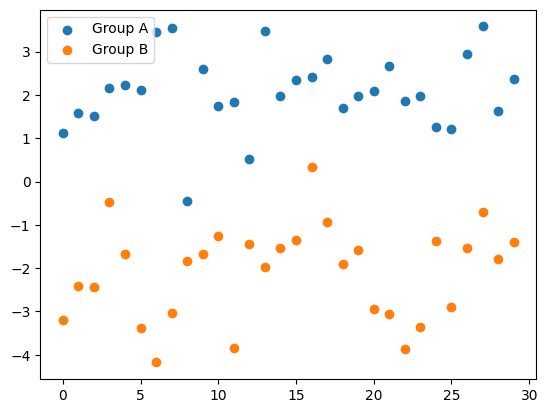

In [21]:
group_a = np.random.randn(30) + 2
group_b = np.random.randn(30) - 2

plt.scatter(range(30), group_a, color="C0", label="Group A")
plt.scatter(range(30), group_b, color="C1", label="Group B")

plt.legend()
plt.show()


---
## Завдання 1. Лінійна регресія

Тренуємо базовий пайплайн на простій лінійній регресії з одним параметром.

$$y = w \cdot x + b + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 1)$$

In [22]:
TASK1_TRUE_W = 2.0
TASK1_TRUE_B = 1.0
TASK1_N = 300

x1 = torch.empty(TASK1_N, 1).uniform_(-5, 5)
noise = 1.0 * torch.randn(TASK1_N, 1)
y1 = TASK1_TRUE_W * x1 + TASK1_TRUE_B + noise

**Вправа 17.** Перш ніж будувати модель — подивись на самі дані.

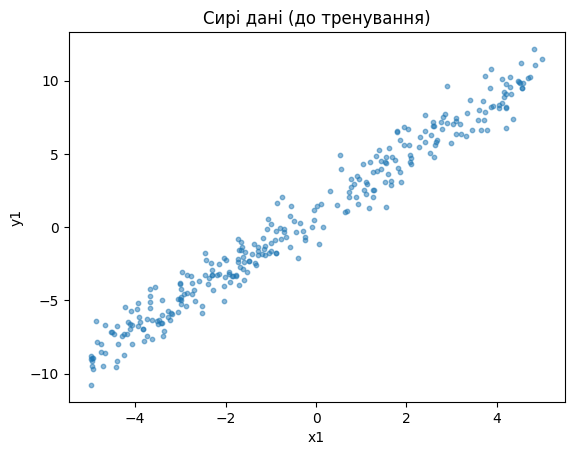

In [23]:
plt.scatter(x1.numpy(), y1.numpy(), s=10, alpha=0.5)
plt.xlabel("x1")
plt.ylabel("y1")
plt.title("Сирі дані (до тренування)")
plt.show()

**Вправа 18.** Розбий дані на train/val/test (70/15/15) — простий зріз тензора за індексами, без `Dataset`/`DataLoader`. Перемішай дані перед зрізом, інакше спліт вийде не випадковим.

In [24]:
perm = torch.randperm(TASK1_N)

x1_shuffled = x1[perm]
y1_shuffled = y1[perm]

train_end = int(0.70 * TASK1_N)
val_end = train_end + int(0.15 * TASK1_N)

x_train1 = x1_shuffled[:train_end]
y_train1 = y1_shuffled[:train_end]

x_val1 = x1_shuffled[train_end:val_end]
y_val1 = y1_shuffled[train_end:val_end]

x_test1 = x1_shuffled[val_end:]
y_test1 = y1_shuffled[val_end:]

print(f"train/val/test: {len(x_train1)}/{len(x_val1)}/{len(x_test1)}")


train/val/test: 210/45/45


**Вправа 19.** Нижче — готовий цикл навчання, кожен крок підписаний окремо. Просто запусти обидві комірки й подивись, як модель наближається до `true` за 100 епох (знімки кожні 30 епох).

In [25]:
task1_model = torch.nn.Linear(in_features=1, out_features=1)
optimizer = torch.optim.SGD(task1_model.parameters(), lr=0.05)
loss_fn = torch.nn.MSELoss()

x_line = torch.linspace(-5, 5, 100).unsqueeze(1)  # сітка для візуалізації лінії
snapshots = []  # (epoch, w, b, y_line_pred) кожні 30 епох

for epoch in range(100):
    # обнулити градієнти з попереднього кроку
    optimizer.zero_grad()
    # forward -- прогноз моделі на поточних w, b
    y_pred = task1_model(x_train1)
    # loss -- наскільки прогноз відрізняється від y_train1
    loss = loss_fn(y_pred, y_train1)
    # backward -- градієнти loss за w і b
    loss.backward()
    # крок оптимізатора -- оновити w і b
    optimizer.step()

    if epoch % 30 == 0 or epoch == 99:
        with torch.no_grad():
            y_line_pred = task1_model(x_line)
        snapshots.append((epoch, task1_model.weight.item(), task1_model.bias.item(), y_line_pred))
        print(f"epoch {epoch:4d}  loss={loss.item():.6f}  "
              f"w={task1_model.weight.item():.4f} (true {TASK1_TRUE_W})  "
              f"b={task1_model.bias.item():.4f} (true {TASK1_TRUE_B})")


epoch    0  loss=10.796704  w=1.7971 (true 2.0)  b=-0.2009 (true 1.0)
epoch   30  loss=1.030498  w=1.9806 (true 2.0)  b=1.0221 (true 1.0)
epoch   60  loss=1.026565  w=1.9829 (true 2.0)  b=1.0764 (true 1.0)
epoch   90  loss=1.026557  w=1.9830 (true 2.0)  b=1.0788 (true 1.0)
epoch   99  loss=1.026557  w=1.9830 (true 2.0)  b=1.0789 (true 1.0)


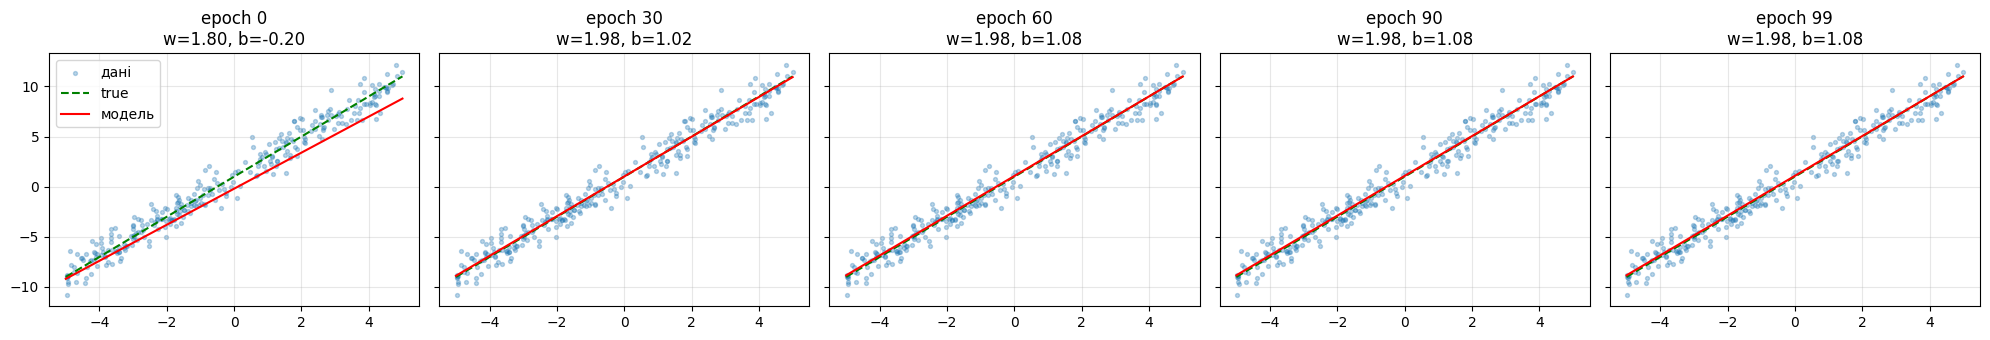

In [26]:
with torch.no_grad():
    y_line_true = TASK1_TRUE_W * x_line + TASK1_TRUE_B

fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 3.5), sharey=True)
for ax, (epoch, w, b, y_line_pred) in zip(axes, snapshots):
    ax.scatter(x1.numpy(), y1.numpy(), s=8, alpha=0.3, label="дані")
    ax.plot(x_line.numpy(), y_line_true.numpy(), "g--", label="true")
    ax.plot(x_line.numpy(), y_line_pred.numpy(), "r-", label="модель")
    ax.set_title(f"epoch {epoch}\nw={w:.2f}, b={b:.2f}")
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


**Вправа 20.** Придумай власний напів-реальний сценарій лінійної залежності
(наприклад: кількість з'їдених пачок чіпсів на тиждень → індекс маси тіла;
години сну → продуктивність; щось своє). У markdown-комірці перед кодом
опиши сценарій: яку залежність ти
закладаєш ($w$, $b$) і чому саме такі значення видались тобі правдоподібними.
Згенеруй дані з шумом (за зразком Завдання 1) і натренуй лінійну регресію
за тим самим патерном — спліт, цикл навчання, перевірка на test. Організуй код тренування у логічні перевикористовувані функції.

### Вправа 20. Лінійна регресія

**Сценарій:** залежність результату тесту від кількості годин підготовки.

Припустимо, що результат тесту можна приблизно описати лінійною залежністю:

$$
y = 5x + 40
$$

де x — кількість годин підготовки, а y — результат тесту в балах.

Вибрані параметри:

- w = 5.0` — кожна додаткова година підготовки в середньому додає 5 балів.
- b = 40.0` — умовний базовий результат без додаткової підготовки.

Такі значення є правдоподібними для навчального прикладу, оскільки підготовка може покращувати результат, але реальна залежність не є ідеально лінійною. Тому до даних буде додано випадковий шум.

Мета — навчити лінійну модель знаходити параметри w і b, а потім перевірити її якість на тестових даних.


Комірка з генерацією даних

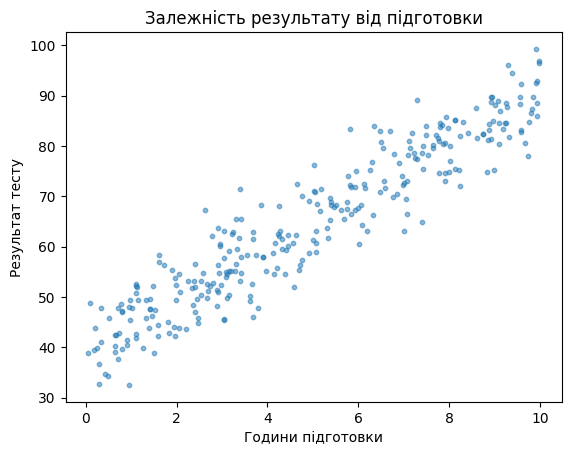

In [27]:
import torch
import matplotlib.pyplot as plt

TASK2_TRUE_W = 5.0
TASK2_TRUE_B = 40.0
TASK2_N = 300

x2 = torch.empty(TASK2_N, 1).uniform_(0, 10)
noise2 = 5.0 * torch.randn(TASK2_N, 1)

y2 = TASK2_TRUE_W * x2 + TASK2_TRUE_B + noise2

plt.scatter(x2.numpy(), y2.numpy(), s=10, alpha=0.5)
plt.xlabel("Години підготовки")
plt.ylabel("Результат тесту")
plt.title("Залежність результату від підготовки")
plt.show()

Функція для розбиття даних

In [28]:
def split_data(x, y, train_ratio=0.70, val_ratio=0.15):
    n = len(x)
    perm = torch.randperm(n)

    x = x[perm]
    y = y[perm]

    train_end = int(train_ratio * n)
    val_end = train_end + int(val_ratio * n)

    x_train = x[:train_end]
    y_train = y[:train_end]

    x_val = x[train_end:val_end]
    y_val = y[train_end:val_end]

    x_test = x[val_end:]
    y_test = y[val_end:]

    return x_train, y_train, x_val, y_val, x_test, y_test


x_train2, y_train2, x_val2, y_val2, x_test2, y_test2 = split_data(x2, y2)

print(f"train/val/test: {len(x_train2)}/{len(x_val2)}/{len(x_test2)}")

train/val/test: 210/45/45


Функція тренування моделі

In [29]:
def train_model(model, x_train, y_train, epochs=1000, lr=0.01):
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr
    )

    loss_fn = torch.nn.MSELoss()

    for epoch in range(epochs):
        optimizer.zero_grad()

        y_pred = model(x_train)
        loss = loss_fn(y_pred, y_train)

        loss.backward()
        optimizer.step()

        if epoch % 500 == 0 or epoch == epochs - 1:
            print(
                f"epoch {epoch:4d} | "
                f"loss={loss.item():.4f}"
            )

    return model

Навчання моделі

In [30]:
task2_model = torch.nn.Linear(in_features=1, out_features=1)

task2_model = train_model(
    task2_model,
    x_train2,
    y_train2,
    epochs=1000,
    lr=0.01
)

epoch    0 | loss=3867.6345
epoch  500 | loss=31.1714
epoch  999 | loss=28.9969


Перевірка на test

In [31]:
def evaluate_model(model, x_test, y_test):
    loss_fn = torch.nn.MSELoss()

    with torch.no_grad():
        y_pred = model(x_test)
        test_loss = loss_fn(y_pred, y_test)

    return test_loss.item()


test_loss2 = evaluate_model(task2_model, x_test2, y_test2)

print(f"Test MSE: {test_loss2:.4f}")

Test MSE: 23.5293


Візуалізація результату

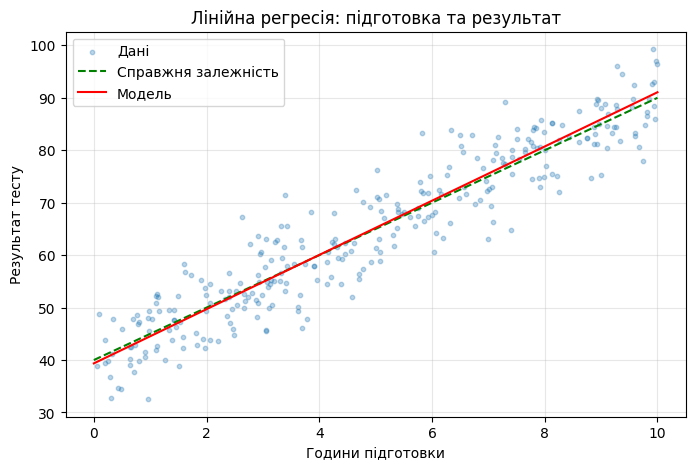

In [32]:
x_line2 = torch.linspace(0, 10, 100).unsqueeze(1)

with torch.no_grad():
    y_line_pred2 = task2_model(x_line2)
    y_line_true2 = TASK2_TRUE_W * x_line2 + TASK2_TRUE_B

plt.figure(figsize=(8, 5))

plt.scatter(
    x2.numpy(),
    y2.numpy(),
    s=10,
    alpha=0.3,
    label="Дані"
)

plt.plot(
    x_line2.numpy(),
    y_line_true2.numpy(),
    "g--",
    label="Справжня залежність"
)

plt.plot(
    x_line2.numpy(),
    y_line_pred2.numpy(),
    "r-",
    label="Модель"
)

plt.xlabel("Години підготовки")
plt.ylabel("Результат тесту")
plt.title("Лінійна регресія: підготовка та результат")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Вправа 21.** Візьми свій пайплайн із з Вправи 20 і
розшир його до **поліноміальної** та **логістичної** регресії:

- **Поліноміальна регресія**: додай ознаки $x^2$, $x^3$ (об'єднай через
  `torch.cat`, наприклад `torch.cat([x, x**2, x**3], dim=1)`), модель тепер
  `nn.Linear(3, 1)` замість `nn.Linear(1, 1)`. MSE-loss і цикл навчання
  лишаються без змін.
- **Логістична регресія**: зміни задачу на класифікацію (два класи), заміни
  `nn.MSELoss()` на [`torch.nn.BCEWithLogitsLoss`](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html)
  — вихід моделі тепер логіт, а не пряме передбачення. Метрика — accuracy
  (`(torch.sigmoid(logits) > 0.5)`), а не MSE.

Навчи модель на своїх або
нових даних.

1. Поліноміальна регресія
Додамо до початкової ознаки x нові ознаки x² та x³. Модель матиме три входи:
y=w
1
​
 x+w
2
​
 x
2
 +w
3
​
 x
3
 +b

Підготовка даних

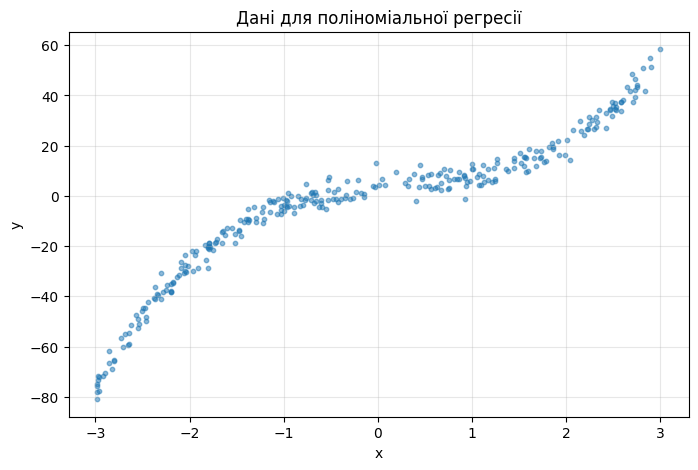

In [33]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

N = 300

x = torch.empty(N, 1).uniform_(-3, 3)

# Справжня поліноміальна залежність
y = 2 * x**3 - 1.5 * x**2 + 4 * x + 3
y = y + 3.0 * torch.randn(N, 1)

plt.figure(figsize=(8, 5))
plt.scatter(x.numpy(), y.numpy(), s=10, alpha=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Дані для поліноміальної регресії")
plt.grid(alpha=0.3)
plt.show()

Створення поліноміальних ознак

In [34]:
X_poly = torch.cat(
    [x, x**2, x**3],
    dim=1
)

print("Форма початкових даних:", x.shape)
print("Форма поліноміальних ознак:", X_poly.shape)

Форма початкових даних: torch.Size([300, 1])
Форма поліноміальних ознак: torch.Size([300, 3])


Розбиття даних

In [35]:
X_train, y_train, X_val, y_val, X_test, y_test = split_data(
    X_poly,
    y
)

print(
    f"train/val/test: "
    f"{len(X_train)}/{len(X_val)}/{len(X_test)}"
)

train/val/test: 210/45/45


Навчання моделі

Для поліноміальної регресії використаємо ту саму функцію train_model, але модель матиме 3 входи.

In [36]:
poly_model = torch.nn.Linear(
    in_features=3,
    out_features=1
)

poly_model = train_model(
    poly_model,
    X_train,
    y_train,
    epochs=5000,
    lr=0.0001
)

epoch    0 | loss=720.1763
epoch  500 | loss=18.9131
epoch 1000 | loss=17.8606
epoch 1500 | loss=17.0451
epoch 2000 | loss=16.3011
epoch 2500 | loss=15.6179
epoch 3000 | loss=14.9904
epoch 3500 | loss=14.4140
epoch 4000 | loss=13.8846
epoch 4500 | loss=13.3981
epoch 4999 | loss=12.9520


Перевірка моделі

In [37]:
poly_test_loss = evaluate_model(
    poly_model,
    X_test,
    y_test
)

print(f"Polynomial regression Test MSE: {poly_test_loss:.4f}")

Polynomial regression Test MSE: 15.4918


Візуалізація

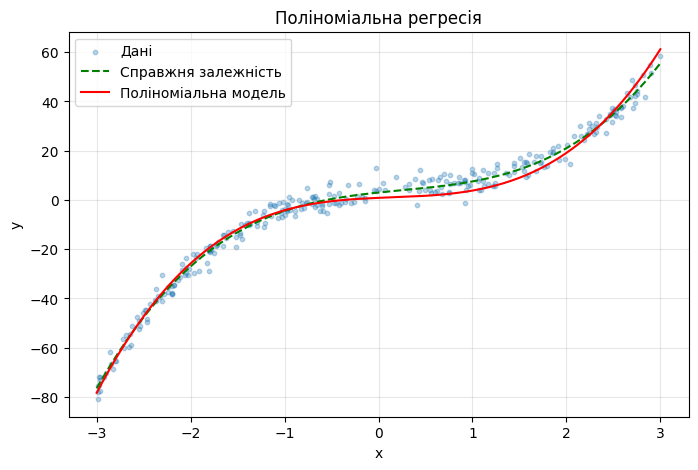

In [38]:
x_line = torch.linspace(-3, 3, 300).unsqueeze(1)

X_line_poly = torch.cat(
    [x_line, x_line**2, x_line**3],
    dim=1
)

with torch.no_grad():
    y_poly_pred = poly_model(X_line_poly)

y_true_line = (
    2 * x_line**3
    - 1.5 * x_line**2
    + 4 * x_line
    + 3
)

plt.figure(figsize=(8, 5))

plt.scatter(
    x.numpy(),
    y.numpy(),
    s=10,
    alpha=0.3,
    label="Дані"
)

plt.plot(
    x_line.numpy(),
    y_true_line.numpy(),
    "g--",
    label="Справжня залежність"
)

plt.plot(
    x_line.numpy(),
    y_poly_pred.numpy(),
    "r-",
    label="Поліноміальна модель"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Поліноміальна регресія")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

2. Логістична регресія
Тепер змінимо задачу на класифікацію. Модель буде визначати, до якого класу належить точка:
клас 0 — нижче умовної межі;
клас 1 — вище умовної межі.
Для цього використаємо BCEWithLogitsLoss. Модель повертатиме логіти, а не ймовірності.

Генерація даних

In [39]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

N = 300

x_class = torch.empty(N, 1).uniform_(-5, 5)

# Ймовірність належності до класу 1
probability = torch.sigmoid(1.5 * x_class)

y_class = torch.bernoulli(probability)

print("Кількість об'єктів:", len(x_class))
print("Клас 0:", int((y_class == 0).sum()))
print("Клас 1:", int((y_class == 1).sum()))

Кількість об'єктів: 300
Клас 0: 162
Клас 1: 138


Візуалізація класів

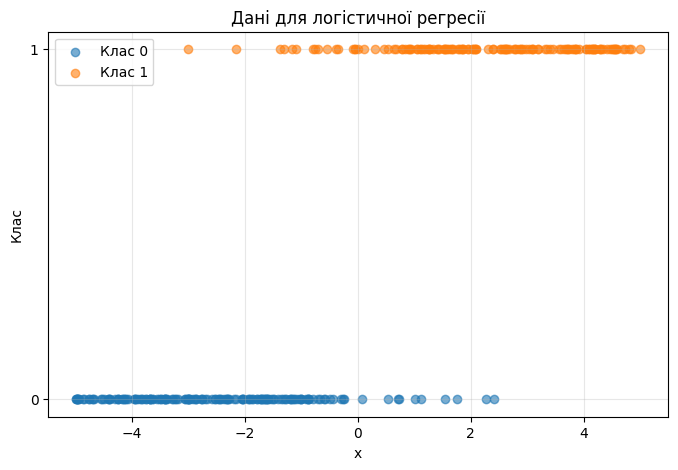

In [40]:
plt.figure(figsize=(8, 5))

plt.scatter(
    x_class[y_class == 0].numpy(),
    y_class[y_class == 0].numpy(),
    label="Клас 0",
    alpha=0.6
)

plt.scatter(
    x_class[y_class == 1].numpy(),
    y_class[y_class == 1].numpy(),
    label="Клас 1",
    alpha=0.6
)

plt.xlabel("x")
plt.ylabel("Клас")
plt.title("Дані для логістичної регресії")
plt.yticks([0, 1])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Розбиття даних

In [41]:
X_train_c, y_train_c, X_val_c, y_val_c, X_test_c, y_test_c = split_data(
    x_class,
    y_class
)

print(
    f"train/val/test: "
    f"{len(X_train_c)}/{len(X_val_c)}/{len(X_test_c)}"
)

train/val/test: 210/45/45


Функція навчання логістичної моделі

In [42]:
def train_logistic_model(
    model,
    x_train,
    y_train,
    epochs=1000,
    lr=0.05
):
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=lr
    )

    loss_fn = torch.nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        optimizer.zero_grad()

        logits = model(x_train)
        loss = loss_fn(logits, y_train)

        loss.backward()
        optimizer.step()

        if epoch % 100 == 0 or epoch == epochs - 1:
            print(
                f"epoch {epoch:4d} | "
                f"loss={loss.item():.4f}"
            )

    return model

Навчання

In [43]:
logistic_model = torch.nn.Linear(
    in_features=1,
    out_features=1
)

logistic_model = train_logistic_model(
    logistic_model,
    X_train_c,
    y_train_c,
    epochs=1000,
    lr=0.05
)

epoch    0 | loss=1.4096
epoch  100 | loss=0.2371
epoch  200 | loss=0.2298
epoch  300 | loss=0.2286
epoch  400 | loss=0.2283
epoch  500 | loss=0.2282
epoch  600 | loss=0.2281
epoch  700 | loss=0.2281
epoch  800 | loss=0.2281
epoch  900 | loss=0.2280
epoch  999 | loss=0.2280


Обчислення accuracy

In [44]:
def evaluate_accuracy(model, x_test, y_test):
    with torch.no_grad():
        logits = model(x_test)

        probabilities = torch.sigmoid(logits)

        predictions = (
            probabilities > 0.5
        ).float()

        accuracy = (
            predictions == y_test
        ).float().mean()

    return accuracy.item()

In [45]:
test_accuracy = evaluate_accuracy(
    logistic_model,
    X_test_c,
    y_test_c
)

print(f"Logistic regression accuracy: {test_accuracy:.4f}")

Logistic regression accuracy: 0.9333


Візуалізація логістичної регресії

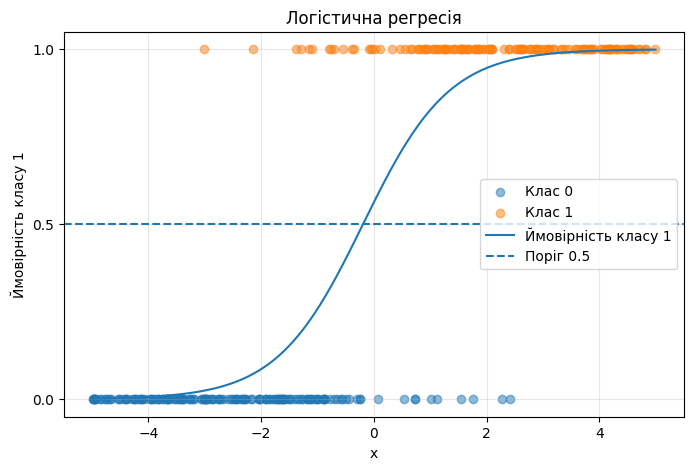

In [46]:
x_line_class = torch.linspace(-5, 5, 300).unsqueeze(1)

with torch.no_grad():
    logits_line = logistic_model(x_line_class)
    probabilities_line = torch.sigmoid(logits_line)

plt.figure(figsize=(8, 5))

plt.scatter(
    x_class[y_class == 0].numpy(),
    y_class[y_class == 0].numpy(),
    alpha=0.5,
    label="Клас 0"
)

plt.scatter(
    x_class[y_class == 1].numpy(),
    y_class[y_class == 1].numpy(),
    alpha=0.5,
    label="Клас 1"
)

plt.plot(
    x_line_class.numpy(),
    probabilities_line.numpy(),
    label="Ймовірність класу 1"
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Поріг 0.5"
)

plt.xlabel("x")
plt.ylabel("Ймовірність класу 1")
plt.title("Логістична регресія")
plt.yticks([0, 0.5, 1])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Вправа 22. Збережи натреновану модель на своєму гугл диску у файлі з назвою model.pt. Збережений файл потрібно буде також здати разом з лабою.*текст курсивом*

In [47]:
from google.colab import drive
import torch

drive.mount('/content/drive')

path = '/content/drive/MyDrive/model.pt'

torch.save(logistic_model.state_dict(), path)

print(f"Модель успішно збережена за адресою: {path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Модель успішно збережена за адресою: /content/drive/MyDrive/model.pt


**Вправа 23.** Встанови [Gradio](https://gradio.app/)
```
!pip install -q gradio
import gradio as gr
```
Завантаж свою модель, збережену в попередній вправі і створи інтерактивну аппку.

In [48]:
import gradio as gr
import torch
import torch.nn as nn

app_model = nn.Linear(in_features=1, out_features=1)

app_model.load_state_dict(torch.load('/content/drive/MyDrive/model.pt'))
app_model.eval()

def predict_class(x_value):
    tensor_x = torch.tensor([[float(x_value)]], dtype=torch.float32)

    with torch.no_grad():
        logits = app_model(tensor_x)
        probability = torch.sigmoid(logits).item() # Обчислення ймовірності через сигмоїду
        predicted_class = 1 if probability > 0.5 else 0

    return {
        "Передбачений клас": predicted_class,
        "Ймовірність класу 1": round(probability, 4)
    }

demo = gr.Interface(
    fn=predict_class,
    inputs=gr.Number(label="Введіть значення ознаки (x)", value=0.0),
    outputs=gr.JSON(label="Результат моделі"),
    title="Лабораторна робота — Інтерактивна логістична регресія",
    description="Введіть числове значення x, щоб отримати прогноз класу та ймовірність за допомогою вашої навченої моделі."
)

demo.launch(inline=False, share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://91f433186633fa7b9e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Cтворення та збереження dataset.csv

In [49]:
import pandas as pd
import os

df_dataset = pd.DataFrame({
    'x': x_class.squeeze().numpy(),
    'y_class': y_class.squeeze().numpy()
})

df_dataset.to_csv('dataset.csv', index=False)

drive_csv_path = '/content/drive/MyDrive/ai_systems/lab1/dataset.csv'
df_dataset.to_csv(drive_csv_path, index=False)

print("Файл dataset.csv успішно створено та збережено!")
print(f"Збережено на Google Диск за адресою: {drive_csv_path}")
print(f"Перші 5 рядків датасету:\n{df_dataset.head()}")

Файл dataset.csv успішно створено та збережено!
Збережено на Google Диск за адресою: /content/drive/MyDrive/ai_systems/lab1/dataset.csv
Перші 5 рядків датасету:
          x  y_class
0  3.822693      1.0
1  4.150040      1.0
2 -1.171362      0.0
3  4.593057      1.0
4 -1.095518      1.0
